<a href="https://colab.research.google.com/github/sc22lg/my_pizza/blob/EG_version/my_train_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cloning into 'EG_optimiser'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 52 (delta 24), reused 16 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 51.54 KiB | 5.15 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/EG_optimiser
Obtaining file:///content/EG_optimiser
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for optim_eg (pyproject.toml) ... done
  Created wheel for optim_eg: filename=optim_eg-0.1.0-0.editable-py3-none-any.whl size=5011 sha256=52e11cd7ded9070e83baba0ecb1f8dfc96c2e5d8278318eca70f36ac1f793df2
  Stored in directory: /tmp/pip-ephem-wheel-cache-vfldmbuy/wheels/73/fe/3c/7df2fded3d27a5af2aaff7b04a3ddc1cbf4d41154388f17d98
Successfully built optim_eg
/content
cuda
k

  0%|          | 0/20000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning:

invalid escape sequence '\/'

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


loss: 4.066, accm: 0.027, vloss: 4.131, vaccm: 0.014, norm: 12.858, acc: 0.023, vacc: 0.000:   3%|▎         | 641/20000 [00:44<22:10, 14.56it/s]


Keyboard interrupt. Gracefully exiting...
Finished.
tensor([[0.1198, 0.0852],
        [0.1162, 0.1101],
        [0.0813, 0.0737],
        ...,
        [0.0858, 0.0733],
        [0.0962, 0.0821],
        [0.1099, 0.0981]])
std(med(col)) 0.012557633239133338
mean(std(row)) 0.1662603598000055


FileNotFoundError: [Errno 2] No such file or directory: 'save/config_kzolulbnod.json'

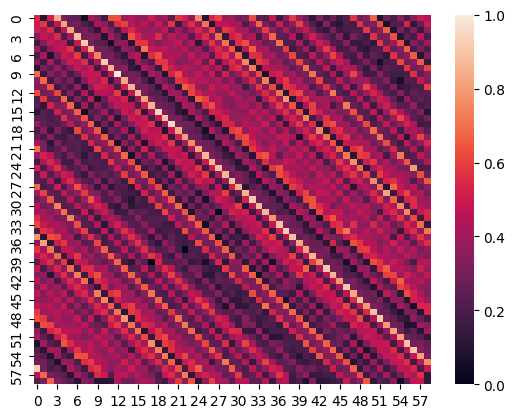

In [1]:
# adapted from https://colab.research.google.com/drive/1F6_1_cWXE5M7WocUcpQWp3v8z4b1jL20 (https://arxiv.org/abs/2301.05217), thanks!

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
import tqdm

import random
import time

from pathlib import Path
import pickle
import os

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"
import plotly.graph_objects as go

from torch.utils.data import DataLoader

from functools import *
import pandas as pd
import gc

# import comet_ml
import wandb
import itertools

!git clone https://github.com/linclab/EG_optimiser.git
%cd EG_optimiser
!pip install -e . --no-deps # use --no-deps if pytorch is already installed (e.g. in Colab)
from optim_eg import adamw_eg, sgd_eg
%cd ..

class HookPoint(nn.Module):
    def __init__(self):
        super().__init__()
        self.fwd_hooks = []
        self.bwd_hooks = []
    def give_name(self, name):
        self.name = name
    def add_hook(self, hook, dir='fwd'):
        def full_hook(module, module_input, module_output):
            return hook(module_output, name=self.name)
        if dir=='fwd':
            handle = self.register_forward_hook(full_hook)
            self.fwd_hooks.append(handle)
        elif dir=='bwd':
            handle = self.register_backward_hook(full_hook)
            self.bwd_hooks.append(handle)
        else:
            raise ValueError(f"Invalid direction {dir}")
    def remove_hooks(self, dir='fwd'):
        if (dir=='fwd') or (dir=='both'):
            for hook in self.fwd_hooks:
                hook.remove()
            self.fwd_hooks = []
        if (dir=='bwd') or (dir=='both'):
            for hook in self.bwd_hooks:
                hook.remove()
            self.bwd_hooks = []
        if dir not in ['fwd', 'bwd', 'both']:
            raise ValueError(f"Invalid direction {dir}")
    def forward(self, x):
        return x

class Embed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_E = nn.Parameter(torch.randn(d_model, d_vocab)/np.sqrt(d_model))
    def forward(self, x):
        return torch.einsum('dbp -> bpd', self.W_E[:, x])

class Unembed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_U = nn.Parameter(torch.randn(d_model, d_vocab)/np.sqrt(d_vocab))
    def forward(self, x):
        return (x @ self.W_U)

# Positional Embeddings
class PosEmbed(nn.Module):
    def __init__(self, max_ctx, d_model):
        super().__init__()
        self.W_pos = nn.Parameter(torch.randn(max_ctx, d_model)/np.sqrt(d_model))
    def forward(self, x):
        return x+self.W_pos[:x.shape[-2]]

# Attention
class Attention(nn.Module):
    def __init__(self, d_model, num_heads, d_head, n_ctx, attn_coeff):
        super().__init__()
        self.W_K = nn.Parameter(torch.randn(num_heads, d_head, d_model)/np.sqrt(d_model))
        self.W_Q = nn.Parameter(torch.randn(num_heads, d_head, d_model)/np.sqrt(d_model))
        self.W_V = nn.Parameter(torch.randn(num_heads, d_head, d_model)/np.sqrt(d_model))
        self.W_O = nn.Parameter(torch.randn(d_model, d_head * num_heads)/np.sqrt(d_model))
        self.attn_coeff = attn_coeff
        self.register_buffer('mask', torch.tril(torch.ones((n_ctx, n_ctx))))
        self.d_head = d_head
        self.hook_k = HookPoint()
        self.hook_q = HookPoint()
        self.hook_v = HookPoint()
        self.hook_z = HookPoint()
        self.hook_attn = HookPoint()
        self.hook_attn_pre = HookPoint()

    def forward(self, x):
        k = self.hook_k(torch.einsum('ihd,bpd->biph', self.W_K, x))
        q = self.hook_q(torch.einsum('ihd,bpd->biph', self.W_Q, x))
        v = self.hook_v(torch.einsum('ihd,bpd->biph', self.W_V, x))
        attn_scores_pre = torch.einsum('biph,biqh->biqp', k, q)
        attn_scores_masked =attn_scores_pre
        normalized = self.hook_attn_pre(attn_scores_masked/np.sqrt(self.d_head))
        normalized = F.softmax(normalized, dim=-1)
        attn_matrix = self.hook_attn(
            normalized*self.attn_coeff+(1-self.attn_coeff))
        z = self.hook_z(torch.einsum('biph,biqp->biqh', v, attn_matrix))
        z_flat = einops.rearrange(z, 'b i q h -> b q (i h)')
        out = torch.einsum('df,bqf->bqd', self.W_O, z_flat)
        return out

# +
class MLP(nn.Module):
    def __init__(self, d_model, d_mlp, act_type):
        super().__init__()
        self.W_in = nn.Parameter(torch.randn(d_mlp, d_model)/np.sqrt(d_mlp))
        self.b_in = nn.Parameter(torch.zeros(d_mlp))
        self.W_out = nn.Parameter(torch.randn(d_model, d_mlp)/np.sqrt(d_model))
        self.b_out = nn.Parameter(torch.zeros(d_model))
        self.act_type = act_type
        # self.ln = LayerNorm(d_mlp, model=self.model)
        self.hook_pre = HookPoint()
        self.hook_post = HookPoint()
        assert act_type in ['ReLU', 'GeLU', 'Tanh']

    def forward(self, x):
        x = self.hook_pre(torch.einsum('md,bpd->bpm', self.W_in, x) + self.b_in)
        if self.act_type=='ReLU':
            x = F.relu(x)
        elif self.act_type=='GeLU':
            x = F.gelu(x)
        elif self.act_type=='Tanh':
            x = F.tanh(x)
        x = self.hook_post(x)
#        return x
        x = torch.einsum('dm,bpm->bpd', self.W_out, x) + self.b_out
        return x

class MyLinear(nn.Module):
    def __init__(self, d_model, act_type):
        super().__init__()
        self.W_in = nn.Parameter(torch.randn(d_model, d_model)/np.sqrt(d_model))
        self.b_in = nn.Parameter(torch.zeros(d_model))
        self.act_type = act_type
        self.hook_pre = HookPoint()
        self.hook_post = HookPoint()
        assert act_type in ['ReLU', 'GeLU', 'Tanh']

    def forward(self, x):
        x = torch.einsum('md,bpd->bpm', self.W_in, self.hook_pre(x)) + self.b_in
        if self.act_type=='ReLU':
            x = F.relu(x)
        elif self.act_type=='GeLU':
            x = F.gelu(x)
        elif self.act_type=='Tanh':
            x = F.tanh(x)
        x = self.hook_post(x)
        return x

# Transformer Block
class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_head, num_heads, n_ctx, act_type, attn_coeff):
        super().__init__()
        self.attn = Attention(d_model, num_heads, d_head, n_ctx, attn_coeff=attn_coeff)
        self.mlp = MLP(d_model, d_model*4,act_type)
        self.hook_attn_out = HookPoint()
        self.hook_mlp_out = HookPoint()
        self.hook_resid_pre = HookPoint()
        self.hook_resid_mid = HookPoint()
        self.hook_resid_post = HookPoint()

    def forward(self, x):
        x = self.hook_resid_mid(x + self.hook_attn_out(self.attn(self.hook_resid_pre(x))))
        x = self.hook_resid_post(x + self.hook_mlp_out(self.mlp(x)))
        return x


# -

# Full transformer
class Transformer(nn.Module):
    def __init__(self, num_layers, d_vocab, d_model, d_head, num_heads, n_ctx, act_type, attn_coeff, use_cache=False, use_ln=True):
        super().__init__()
        assert 0<=attn_coeff<=1
        print('parameters', num_layers, d_vocab, d_model, d_head, num_heads, n_ctx, act_type, attn_coeff, use_cache, use_ln)
        self.cache = {}
        self.use_cache = use_cache

        self.embed = Embed(d_vocab, d_model)
        self.pos_embed = PosEmbed(n_ctx, d_model)
        self.unembed = Unembed(d_vocab, d_model)
        self.use_ln = use_ln
        self.blocks = nn.ModuleList([TransformerBlock(d_model, d_head, num_heads, n_ctx, act_type, attn_coeff) for i in range(num_layers)])

        for name, module in self.named_modules():
            if type(module)==HookPoint:
                module.give_name(name)

    def forward(self, x):
        x = self.embed(x)
        x = self.pos_embed(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.unembed(x)
        return x

    def set_use_cache(self, use_cache):
        self.use_cache = use_cache

    def hook_points(self):
        return [module for name, module in self.named_modules() if 'hook' in name]

    def remove_all_hooks(self):
        for hp in self.hook_points():
            hp.remove_hooks('fwd')
            hp.remove_hooks('bwd')

    def cache_all(self, cache, incl_bwd=False):
        # Caches all activations wrapped in a HookPoint
        def save_hook(tensor, name):
            cache[name] = tensor.detach()
        def save_hook_back(tensor, name):
            cache[name+'_grad'] = tensor[0].detach()
        for hp in self.hook_points():
            hp.add_hook(save_hook, 'fwd')
            if incl_bwd:
                hp.add_hook(save_hook_back, 'bwd')

    def parameters_norm(self):
        # Returns the l2 norm of all parameters
        return sum([torch.sum(p*p).item() for p in self.parameters()])**0.5

    def l2_norm(self):
        # Returns the l2 norm of all parameters
        return sum([torch.sum(p*p) for p in self.parameters()])

    def parameters_flattened(self):
        # Returns all parameters as a single tensor
        return torch.cat([p.view(-1) for p in self.parameters()]).detach().cpu().numpy()


class Linearformer(nn.Module):
    def __init__(self, num_layers, d_vocab, d_model, d_head, num_heads, n_ctx, act_type, attn_coeff, use_cache=False, use_ln=True):
        super().__init__()
        print('parameters(L)', num_layers, d_vocab, d_model, d_head, num_heads, n_ctx, act_type, attn_coeff, use_cache, use_ln)
        self.cache = {}
        self.use_cache = use_cache
        self.attn_coeff = attn_coeff

        self.embed = Embed(d_vocab, d_model//n_ctx)
        #self.pos_embed = PosEmbed(n_ctx, d_model)
        self.unembed = Unembed(d_vocab, d_model)
        self.use_ln = use_ln
        self.blocks = nn.ModuleList([MyLinear(d_model, act_type) for i in range(num_layers)])
        self.padder = nn.ConstantPad1d((0,d_model%n_ctx),0)

        for name, module in self.named_modules():
            if type(module)==HookPoint:
                module.give_name(name)

    def forward(self, x):
        x = self.embed(x)
        #print(x.shape)
        x = x.reshape(-1,1,x.shape[1]*x.shape[2])
        #print(x.shape)
        x = self.padder(x)
        #print(x.shape)
        #print(x.shape)
        assert len(x.shape)==3 and x.shape[1:]==(1,d_model)
        #x = self.pos_embed(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.unembed(x)
        return x

    def set_use_cache(self, use_cache):
        self.use_cache = use_cache

    def hook_points(self):
        return [module for name, module in self.named_modules() if 'hook' in name]

    def remove_all_hooks(self):
        for hp in self.hook_points():
            hp.remove_hooks('fwd')
            hp.remove_hooks('bwd')

    def cache_all(self, cache, incl_bwd=False):
        # Caches all activations wrapped in a HookPoint
        def save_hook(tensor, name):
            cache[name] = tensor.detach()
        def save_hook_back(tensor, name):
            cache[name+'_grad'] = tensor[0].detach()
        for hp in self.hook_points():
            hp.add_hook(save_hook, 'fwd')
            if incl_bwd:
                hp.add_hook(save_hook_back, 'bwd')

    def parameters_norm(self):
        # Returns the l2 norm of all parameters
        return sum([torch.sum(p*p).item() for p in self.parameters()])**0.5

    def l2_norm(self):
        # Returns the l2 norm of all parameters
        return sum([torch.sum(p*p) for p in self.parameters()])

    def parameters_flattened(self):
        # Returns all parameters as a single tensor
        return torch.cat([p.view(-1) for p in self.parameters()]).detach().cpu().numpy()

DEVICE='cuda'
#DEVICE='cuda:'+str(random.randint(0,1))
print(DEVICE)
class MyAddDataSet(torch.utils.data.Dataset):
    def __init__(self, func, C, diff_vocab=False, eqn_sign=False):
        self.func = func
        dim = 2
        self.dim = dim
        self.C = C
        self.inputs = []
        self.outputs = []
        self.vocab=C
        if diff_vocab:
            self.vocab*=2
        if eqn_sign:
            self.vocab+=1
            self.dim+=1
        self.vocab_out=0
        for p in range(C**dim):
            x = np.unravel_index(p, (C,)*dim)
            o=self.func(x)
            s=[x[0],x[1]]
            if diff_vocab:
                s[1]+=C
            if eqn_sign:
                s.append(self.vocab-1)
            self.inputs.append(s)
            self.outputs.append(o)
            self.vocab_out=max(self.vocab_out, o+1)
        if self.vocab_out!=C:
            print(f'warning {self.vocab_out=} neq to {C=}')
        self.inputs = torch.tensor(self.inputs, dtype=torch.long, device=DEVICE)
        self.outputs = torch.tensor(self.outputs, dtype=torch.long, device=DEVICE)
        print(self.inputs,self.outputs)
    def __len__(self):
        return len(self.outputs)
    def __getitem__(self, idx):
        return self.inputs[idx], self.outputs[idx]

def cross_entropy_high_precision(logits, labels):
    # Shapes: batch x vocab, batch
    # Cast logits to float64 because log_softmax has a float32 underflow on overly
    # confident data and can only return multiples of 1.2e-7 (the smallest float x
    # such that 1+x is different from 1 in float32). This leads to loss spikes
    # and dodgy gradients
    logprobs = F.log_softmax(logits.to(torch.float64), dim=-1)
    prediction_logprobs = torch.gather(logprobs, index=labels[:, None], dim=-1)
    loss = -torch.mean(prediction_logprobs)
    return loss

def run_experiment(config):
    exp_name=config['name']
    print('parsing func',config['funcs'])
    config['func']=eval(config['funcs'])
    useLinear=config.get('use_linear',False)
    full_dataset = MyAddDataSet(func=config['func'],C=config['C'],diff_vocab=config['diff_vocab'],eqn_sign=config['eqn_sign'])
    model = (Linearformer if useLinear else Transformer)(
        num_layers=config.get('n_layers',1),
        num_heads=config['n_heads'],
        d_model=config['d_model'],
        d_head=config.get('d_head',config['d_model']//config['n_heads']),
        attn_coeff=config['attn_coeff'],
        d_vocab=full_dataset.vocab,
#        attention_dir=config.get('attention_dir','bidirectional'),
        act_type=config.get('act_fn','relu'),
        n_ctx=full_dataset.dim,
#        normalization_type=None,
    )
    model.to(DEVICE)
    train_size = int(config['frac'] * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])
    print('random split',len(train_dataset),len(test_dataset))
    batch_size = config.get('batch_size',len(full_dataset))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    opt = None
    if config.get('optimiser',None)=='EG':
      opt = adamw_eg.AdamWeg(model.parameters(), lr=config.get('lr',1e-3),weight_decay=config.get('weight_decay',1e-4),betas=(0.9,0.98)) # OPTIMISER CHOICE
    else:
      opt = optim.AdamW(model.parameters(),lr=config.get('lr',1e-3),weight_decay=config.get('weight_decay',1e-4),betas=(0.9,0.98))

    scheduler = optim.lr_scheduler.LambdaLR(opt, lambda step: min(step/10, 1)) # 10 epoch warmup
    print(config.get('lr',1e-3),config.get('weight_decay',1e-4))
    print(opt,scheduler)
    losses=[]
    accs=[]
    losses_val=[]
    accs_val=[]
    norms=[]
    loss_val=10
    acc_val=0
    stop=None
    best_train_acc=0.
    best_test_acc=0.
    perfect_train_time=None
    perfect_test_time=None
    pbar = tqdm.tqdm(range(config.get('epoch',10000)))
    gaps=[]
    early_stop_a=2
    early_stop_b=1
    if config.get('early_stop',None) is not None:
        early_stop_a, early_stop_b = config['early_stop']
    early_stop_timer=0
    #model.train()
    run = wandb.init(reinit=True,config=config,project='modadd_longer')#,settings=wandb.Settings(start_method="spawn"))
    try:
        for i in pbar:
            def evaluation():
                nonlocal best_test_acc
                nonlocal perfect_test_time
                nonlocal early_stop_timer
                nonlocal early_stop_a
                nonlocal early_stop_b
                # evaluate on test set, return loss and accuracy
                # with torch.inference_mode():
                    #model.eval()
                losses_eval=[]
                accs_eval=[]
                for inp,ans in test_loader:
                    # print(inp.shape)
                    out = model(inp)[:,-1,:]
                    loss = cross_entropy_high_precision(out,ans)
                    acc = torch.sum((out.argmax(dim=1)==ans).float())/len(ans)
                    # print(inp,'test',out.argmax(dim=1),ans)
#                    acc = (out.argmax(dim=1)==ans).float().mean()
                    losses_eval.append(loss.item())
                    accs_eval.append(acc.item())
                    # print(loss,acc)
                #print(losses_eval,accs_eval)
                eval_loss, eval_acc = np.mean(losses_eval), np.mean(accs_eval)
                best_test_acc = max(best_test_acc, eval_acc)
                if eval_acc==1. and perfect_test_time is None:
                    perfect_test_time = i
                if eval_acc>=early_stop_a:
                    early_stop_timer+=1
                else:
                    early_stop_timer=0
                #print(eval_loss,eval_acc)
                return eval_loss, eval_acc
            if early_stop_timer>=early_stop_b:
                break
            for inp,ans in train_loader:
                #print(inp.shape,inp.dtype)
                # print(inp,'train')
                #print(len(inp))
                #model.train()
                out = model(inp)[:,-1,:]
                loss = cross_entropy_high_precision(out,ans)
                loss_val, acc_val = evaluation()
                #print(loss_val,acc_val)
                loss.backward()
                # clip gradients
                #if config.get('clip',None) is not None:
                #    nn.utils.clip_grad_norm_(model.parameters(), config['clip'])
                opt.step()
                scheduler.step()
                opt.zero_grad()
                acc = (out.argmax(dim=1)==ans).float().mean()
                norm = sum([torch.sum(p*p).item() for p in model.parameters()])**0.5
                #sum(p.norm()**2 for p in model.parameters()).sqrt().item()
                losses.append(loss.item())
                accs.append(acc.item())
                losses_val.append(loss_val)
                accs_val.append(acc_val)
                norms.append(norm)

                best_train_acc=max(best_train_acc,acc.item())
                if acc.item()==1. and perfect_train_time is None:
                    perfect_train_time = i
                gaps.append(best_train_acc-best_test_acc)
                pbar.set_description(f"loss: {loss.item():.3f}, accm: {best_train_acc:.3f}, vloss: {loss_val:.3f}, vaccm: {best_test_acc:.3f}, norm: {norm:.3f}, acc: {acc.item():.3f}, vacc: {acc_val:.3f}")
                #print(f"loss: {loss.item():.3f}, accm: {best_train_acc:.3f}, vloss: {loss_val:.3f}, vaccm: {best_test_acc:.3f}, norm: {norm:.3f}, acc: {acc.item():.3f}, vacc: {acc_val:.3f}")
                run.log({'training_loss': loss.item(),
                'validation_loss': loss_val,
                'training_accuracy': acc.item(),
                'validation_accuracy': acc_val,
                'parameter_norm': norm,
                'best_train_accuracy': best_train_acc,
                'best_test_accuracy': best_test_acc,
                'generalization_gap': best_train_acc-best_test_acc,
                'generalization_delay1': sum(gaps)})
    except KeyboardInterrupt:
        print('Keyboard interrupt. Gracefully exiting...')
        pass
    print('Finished.')
    generalization_gap=best_train_acc-best_test_acc
    generalization_delay1=sum(gaps)
    generalization_delay2=sum(max(t-(best_train_acc-best_test_acc),0) for t in gaps)
    run.summary["generalization_delay2"] = generalization_delay2
    # run.finish()
    return dict(
        losses=losses,
        accs=accs,
        losses_val=losses_val,
        accs_val=accs_val,
        norms=norms,
        model=model,
        config=config,
        generalization_gap=generalization_gap,
        generalization_delay1=generalization_delay1,
        generalization_delay2=generalization_delay2,
        best_train_acc=best_train_acc,
        best_test_acc=best_test_acc,
        perfect_train_time=perfect_train_time,
        perfect_test_time=perfect_test_time,
        dataset = full_dataset,
        run=run
    )

import random
import string

while True:
    letters_and_numbers = string.ascii_lowercase + string.digits.replace('0', '')
    run_name = ''.join(random.choices(letters_and_numbers, k=10))
    print(run_name)
    C=59
    n_layers=1
    diff_vocab=0
    eqn_sign=0
    d_model=128
    print(f'd={d_model}')
    config=dict(
        name='modadd_'+str(C),
        funcs='lambda x: (x[0]+x[1])%'+str(C),
        C=C,
        n_heads=4,
        d_model=d_model,
        n_layers=n_layers,
        attention_dir='casual',
        act_fn='ReLU',
        epoch=20000,
        batch_size=C*C,
        lr=1e-3,
        weight_decay=2.,
        frac=0.8,
        attn_coeff=1,
        runid=run_name,
        diff_vocab=diff_vocab,
        eqn_sign=eqn_sign,
        optimiser = "EG" # EG / GD
    )
    result_modadd=run_experiment(config)
    dataset = result_modadd['dataset']
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=C*C)
    model = result_modadd['model']
    oo=[[0]*C for _ in range(C)]
    oc=[[0]*C for _ in range(C)]
    for x,y in dataloader:
        with torch.inference_mode():
            model.eval()
            o=model(x)[:,-1,:]
            o0=o[list(range(len(x))),y]
            o0=o0.cpu()
            x=x.cpu()
            for p,q in zip(o0,x):
                A,B=int(q[0].item()),int(q[1].item())
                oo[(A+B)%C][(A-B)%C]=p.item()
            o[list(range(len(x))),y]=float("-inf")
            o1=o.topk(dim=-1,k=2).values.cpu()
            print(o1)
            for p,q in zip(o1,x):
                A,B=int(q[0].item()),int(q[1].item())
                oc[(A+B)%C][(A-B)%C]=p[0].item()
    # use seaborn to plot the heatmap of oo
    import seaborn as sns
    run=result_modadd['run']
    oo=np.array(oc)
    dd=np.mean(np.std(oo,axis=0))/np.std(oo.flatten())
    #print('dd',dd)
    run.summary['distance_irrelevancy']=dd
    run.summary['logits']=oo
    mi,mx=np.min(oo),np.max(oo)
    oo=(oo-mi)/(mx-mi)
    run.summary['logits_normalized']=oo
    sns.heatmap(np.array(oo))
    sb=[]
    sx=[]
    sc=[]
    ss=[]
    for i in range(C):
        s=oo[:,i]
        sb.append(np.median(s))
        ss.append(np.mean(s))
        sx.append(np.std(oo[i]))
    print('std(med(col))',np.std(sb))
    print('mean(std(row))',np.mean(sx))
    run.summary['std_med_col']=np.std(sb)
    run.summary['mean_std_row']=np.mean(sx)
    run.summary['std_mean_col']=np.std(ss)
    run.summary['med_std_row']=np.median(sx)
    model_name=f'model_{run_name}.pt'
    model=result_modadd['model']
    torch.save(model.state_dict(),model_name)
    import json
    config['func']=None
    with open(f'save/config_{run_name}.json','w') as f:
        json.dump(config,f)
    run.finish()

# !python -m wandb offline

In [ ]:
torch.save(model.state_dict(),'model.pth')
